# Perfilado de Datos — Cruz Azul F.C. Intelligence
**Materia:** Calidad y Preprocesamiento de Datos  
**Framework:** DAMA-DMBOK  
**Etapas cubiertas:** II — Perfilado previo · IV — Perfilado posterior a limpieza

Este notebook realiza el perfilado de las fuentes de datos antes de la limpieza
(**MODO = 'ANTES'**) y del dataset maestro ya procesado (**MODO = 'DESPUES'**).
No incluye ninguna operación de limpieza.

---

### Fuentes de datos

| Etapa | Archivo | Formato | Descripción |
|---|---|---|---|
| ANTES | `partidos_historicos_ligamx.csv` | CSV | Partidos Liga MX 2010–2024 |
| ANTES | `perfiles_jugadores_historico.json` | JSON | Perfiles de jugadores multi-fuente |
| ANTES | `scouting_historico_ligamx.txt` | TXT (ancho fijo) | Vista consolidada de scouting |
| ANTES | `valor_mercado_historico.xlsx` | XLSX | Valores de mercado y métricas |
| DESPUES | `master_jugadores.parquet` | Parquet | Dataset maestro de jugadores |
| DESPUES | `master_partidos.parquet` | Parquet | Dataset maestro de partidos |

---

### Dimensiones DAMA-DMBOK evaluadas

| Dimensión | Qué medimos | Problemática |
|---|---|---|
| Completitud | % de valores nulos por columna | #2 Valores de mercado faltantes |
| Unicidad | % de registros duplicados | #3 Jugadores con doble registro |
| Validez | Tipos de dato, patrones, rangos | #5 Escalas incomparables |
| Consistencia | Formatos heterogéneos entre fuentes | #1 Nombres inconsistentes · #4 Equipos renombrados |
| Exactitud | Outliers y valores fuera de rango | #5 Métricas inválidas |
| Actualidad | Rango temporal de los datos | — |

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
warnings.filterwarnings('ignore')

# Paleta Cruz Azul 
AZUL  = '#003DA5'
MORADO  = "#8C9FF5"
GRIS  = '#888888'
COLORES = [AZUL, MORADO, GRIS, '#004F9E', '#A00020']

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

# Rutas 
BASE    = os.path.abspath(os.path.join(os.getcwd(), '..'))
FINAL   = os.path.join(BASE, 'datos_final')
MASTER  = os.path.join(BASE, 'datos_master')
REPORTS = os.path.join(BASE, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Modo de ejecucion 
# Cambia a 'DESPUES' para perfilar el dataset maestro post-limpieza
MODO = 'ANTES' # 'ANTES' | 'DESPUES'

print(f'Modo de perfilado: {MODO}')
print(f'Ruta de datos    : {FINAL if MODO == "ANTES" else MASTER}')
print(f'Reportes en      : {REPORTS}')

Modo de perfilado: ANTES
Ruta de datos    : /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_final
Reportes en      : /Users/milenafer/Desktop/claude/Calidad_PFinal/reports


---
## 1. Carga de datos

La carga varía según el `MODO`:
- **ANTES** — Se leen las 4 fuentes heterogéneas desde `datos_final/` (CSV, JSON, TXT, XLSX).
- **DESPUES** — Se leen los 2 datasets maestros desde `datos_master/` (Parquet).

In [2]:
def cargar_datos(modo):
    """cargar_datos
    Carga las fuentes de datos segun la etapa del pipeline (antes o después de
    la limpieza) y devuelve un diccionario con los DataFrames disponibles.
    ---
    :param:
        - modo (str): 'ANTES' para leer desde datos_final/; 'DESPUES' para
          leer desde datos_master/.
    ---
    :return:
        dict[str, pd.DataFrame]: clave = nombre descriptivo de la fuente,
        valor = DataFrame cargado.
    """
    dfs = {}

    if modo == 'ANTES':
        # Fuente 1: Partidos — CSV
        ruta_csv = os.path.join(FINAL, 'partidos_historicos_ligamx.csv')
        dfs['Partidos CSV'] = pd.read_csv(ruta_csv)

        # Fuente 2: Jugadores — JSON anidado
        ruta_json = os.path.join(FINAL, 'perfiles_jugadores_historico.json')
        with open(ruta_json, encoding='utf-8') as f:
            raw = json.load(f)
        dfs['Jugadores JSON'] = pd.json_normalize(raw['jugadores'])

        # Fuente 3: Scouting — TXT ancho fijo
        ruta_txt = os.path.join(FINAL, 'scouting_historico_ligamx.txt')
        dfs['Scouting TXT'] = pd.read_fwf(
            ruta_txt, skiprows=[1],
            names=['ID','NOMBRE_TM','NOMBRE_FIFA','NOMBRE_CSV','POS','NAC',
                   'EXT','EDAD','TEMP','EQUIPO','OVR','MVAL_EUR','TPAG_EUR',
                   'GOLES','ASIS','MINS','G_A_90'])

        # Fuente 4: Valor de mercado — XLSX
        ruta_xlsx = os.path.join(FINAL, 'valor_mercado_historico.xlsx')
        dfs['Valor Mercado XLSX'] = pd.read_excel(ruta_xlsx, engine='openpyxl')

    else: # DESPUES
        dfs['Master Jugadores'] = pd.read_parquet(
            os.path.join(MASTER, 'master_jugadores.parquet'))
        dfs['Master Partidos']  = pd.read_parquet(
            os.path.join(MASTER, 'master_partidos.parquet'))

    return dfs


DATOS = cargar_datos(MODO)

for nombre, df in DATOS.items():
    print(f'{nombre:<25}: {df.shape[0]:>6,} filas x {df.shape[1]:>3} columnas')

Partidos CSV             :  4,090 filas x  17 columnas
Jugadores JSON           :  1,158 filas x  36 columnas
Scouting TXT             :  1,151 filas x  17 columnas
Valor Mercado XLSX       :  1,165 filas x  26 columnas


---
## 2. Funciones auxiliares de perfilado

Funciones reutilizables alineadas con las dimensiones DAMA-DMBOK.

In [3]:
def perfil_basico(df, nombre):
    """perfil_basico
    Imprime un resumen de calidad de un DataFrame: dimensiones, nulos,
    duplicados, tipos de dato y muestra las primeras 3 filas.
    ---
    :param:
        - df (pd.DataFrame): dataset a perfilar.
        - nombre (str): nombre descriptivo de la fuente.
    ---
    :return:
        None
    """
    total = df.shape[0] * df.shape[1]
    nulos = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f'\n{"-*" * 32}')
    print(f'  {nombre}')
    print(f'{"-*" * 32}')
    print(f'  Filas          : {df.shape[0]:>8,}')
    print(f'  Columnas       : {df.shape[1]:>8}')
    print(f'  Celdas totales : {total:>8,}')
    print(f'  Nulos totales  : {nulos:>8,}  ({nulos/total*100:.1f}%)')
    print(f'  Duplicados     : {dups:>8,}  ({dups/df.shape[0]*100:.1f}%)')
    print(f'\n  Tipos de dato:')
    for dt, cnt in df.dtypes.astype(str).value_counts().items():
        print(f'    {dt:<14}: {cnt} col(s)')
    print()
    display(df.head(3))


def grafica_nulos(df, titulo, umbral_critico=50, color=None):
    """grafica_nulos
    Genera una barra horizontal con el porcentaje de nulos por columna.
    Las columnas con mas del umbral_critico % se muestran en morado.
    Si no hay nulos, imprime un mensaje en lugar de la grafica.
    ---
    :param:
        - df (pd.DataFrame): dataset a analizar.
        - titulo (str): título de la grafica.
        - umbral_critico (float): porcentaje a partir del cual la barra es morada.
        - color (str | None): color base de las barras; usa AZUL si None.
    ---
    :return:
        None
    """
    color = color or AZUL
    pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    pct = pct[pct > 0]
    if pct.empty:
        print(f'  [{titulo}] Sin valores nulos :)')
        return
    colores_bar = [MORADO if v >= umbral_critico else color for v in pct.values]
    fig, ax = plt.subplots(figsize=(10, max(3, len(pct) * 0.38)))
    bars = ax.barh(pct.index, pct.values, color=colores_bar)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 110)
    for bar, val in zip(bars, pct.values):
        ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Porcentaje de Nulos por Columna — {titulo}', fontweight='bold')
    ax.set_xlabel('% de valores nulos')
    plt.tight_layout()
    plt.show()


def grafica_tipos(df, titulo):
    """grafica_tipos
    Genera un pie chart con la distribucion de tipos de dato de las columnas.
    ---
    :param:
        - df (pd.DataFrame): dataset a analizar.
        - titulo (str): título de la gráfica.
    ---
    :return:
        None
    """
    conteo = df.dtypes.astype(str).value_counts()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.pie(conteo.values, labels=conteo.index, autopct='%1.0f%%',
           colors=COLORES[:len(conteo)], startangle=90)
    ax.set_title(f'Tipos de dato — {titulo}', fontweight='bold')
    plt.tight_layout()
    plt.show()


def grafica_distribucion_num(df, cols, titulo, bins=40):
    """grafica_distribucion_num
    Genera histogramas para un conjunto de columnas numericas del DataFrame.
    Muestra hasta 4 columnas en una sola fila; si hay mas, usa multiples filas.
    ---
    :param:
        - df (pd.DataFrame): dataset con las columnas a graficar.
        - cols (list[str]): lista de nombres de columnas numéricas.
        - titulo (str): supertítulo de la figura.
        - bins (int): numero de bins del histograma (default: 40).
    ---
    :return:
        None
    """
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print('  No se encontraron las columnas especificadas.')
        return
    ncols = min(4, len(cols))
    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        datos = df[col].dropna()
        axes[i].hist(datos, bins=bins, color=AZUL, edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_ylabel('Frecuencia')
        q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
        iqr = q3 - q1
        n_out = ((datos < q1 - 1.5*iqr) | (datos > q3 + 1.5*iqr)).sum()
        axes[i].set_xlabel(f'Outliers IQR: {n_out}')
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()


def grafica_boxplot_outliers(df, cols, titulo):
    """grafica_boxplot_outliers
    Genera boxplots para detectar visualmente outliers en columnas numericas.
    ---
    :param:
        - df (pd.DataFrame): dataset con las columnas a graficar.
        - cols (list[str]): lista de nombres de columnas numericas.
        - titulo (str): superttulo de la figura.
    ---
    :return:
        None
    """
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    ncols = min(4, len(cols))
    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor=AZUL, alpha=0.6),
                        medianprops=dict(color=MORADO, linewidth=2),
                        flierprops=dict(marker='o', color=MORADO, markersize=4))
        axes[i].set_title(col, fontweight='bold')
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()


print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


---
## 3. Perfilado por fuente

Se aplican las funciones auxiliares a cada fuente disponible según el `MODO`.

### 3.1 Partidos Liga MX — CSV (ANTES) / Parquet (DESPUES)

**Dimensiones:** Completitud · Validez · Consistencia  
**Problemáticas:** #4 — Inconsistencia en nombres de equipos entre temporadas  

Contiene 4 080 partidos del torneo Apertura/Clausura 2010–2024.


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Partidos CSV
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    4,090
  Columnas       :       17
  Celdas totales :   69,530
  Nulos totales  :        0  (0.0%)
  Duplicados     :       10  (0.2%)

  Tipos de dato:
    object        : 9 col(s)
    int64         : 8 col(s)



,match_id,season,season_year,half,round,date,home_team_id,home_team,away_team_id,away_team,home_goals,away_goals,home_goals_ht,away_goals_ht,venue,result_home,involves_cruz_azul
0,1000,Apertura 2010,2010,apertura,1,2010-07-01,T012,Club Tijuana,T008,Atlas Guadalajara,1,1,1,1,Estadio Caliente,D,0
1,1001,Apertura 2010,2010,apertura,1,2010-07-01,T007,Pumas UNAM,T017,Puebla FC,2,1,1,1,Estadio Olímpico Universitario,W,0
2,1002,Apertura 2010,2010,apertura,1,2010-07-01,T002,América,T015,Impulsora Necaxa,3,1,3,0,Estadio Azteca,W,0


  [Partidos CSV] Sin valores nulos :)


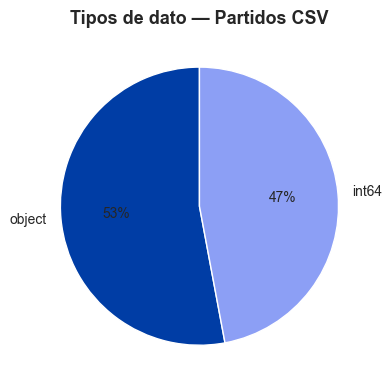

In [4]:
clave_partidos = 'Partidos CSV' if MODO == 'ANTES' else 'Master Partidos'
df_partidos = DATOS[clave_partidos]

perfil_basico(df_partidos, clave_partidos)
grafica_nulos(df_partidos, clave_partidos)
grafica_tipos(df_partidos, clave_partidos)

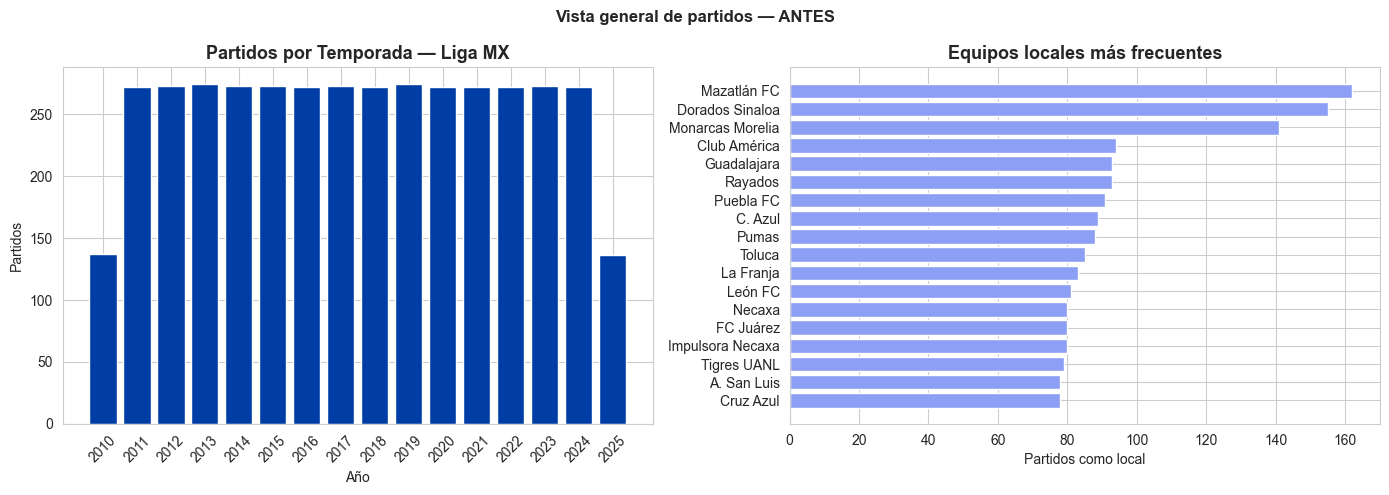


Alerta — Consistencia (Problemática #4):
  Equipos únicos en columna "home_team": 51
  Liga MX tiene 18 equipos activos — valores mayores sugieren renombrados históricos.

  Equipos únicos detectados:
    A. San Luis
    América
    Atlas
    Atlas Guadalajara
    Atlético San Luis
    Bravos de Juárez
    C. Azul
    CF América
    CF Monterrey
    Chivas
    Club América
    Club Atlas
    Club León
    Club Necaxa
    Club Puebla
    Club Tijuana
    Cruz Azul
    Cruz Azul FC
    Deportivo Guadalajara
    Deportivo Toluca
    Dorados Sinaloa
    FC Juárez
    Gallos Blancos
    Guadalajara
    Impulsora Necaxa
    Juárez
    La Franja
    León
    León FC
    Mazatlán FC
    Monarcas Morelia
    Monterrey
    Necaxa
    Puebla FC
    Pumas
    Pumas UNAM
    Querétaro
    Querétaro FC
    Rayados
    San Luis
    Santos
    Santos Laguna
    Santos Laguna FC
    Tigres
    Tigres UANL
    Tijuana
    Toluca
    Toluca FC
    UANL Tigres
    UNAM Pumas
    Xoloitzcuintles


In [5]:
# Distribucion de partidos por temporada
col_season = 'season_year' if 'season_year' in df_partidos.columns else 'season'
col_local  = 'home_team'   if 'home_team'   in df_partidos.columns else 'equipo_local'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo_temp = df_partidos[col_season].value_counts().sort_index()
axes[0].bar(conteo_temp.index.astype(str), conteo_temp.values, color=AZUL)
axes[0].set_title('Partidos por Temporada — Liga MX', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Partidos')
axes[0].tick_params(axis='x', rotation=45)

top_eq = df_partidos[col_local].value_counts().head(18)
axes[1].barh(top_eq.index[::-1], top_eq.values[::-1], color=MORADO)
axes[1].set_title('Equipos locales más frecuentes', fontweight='bold')
axes[1].set_xlabel('Partidos como local')

plt.suptitle(f'Vista general de partidos — {MODO}', fontweight='bold')
plt.tight_layout()
plt.show()

# Alerta: consistencia de nombres de equipos
n_eq = df_partidos[col_local].nunique()
print(f'\nAlerta — Consistencia (Problemática #4):')
print(f'  Equipos únicos en columna "{col_local}": {n_eq}')
print(f'  Liga MX tiene 18 equipos activos — valores mayores sugieren renombrados históricos.')
# Detectar posibles renombrados
equipos_unicos = sorted(df_partidos[col_local].dropna().unique())
print(f'\n  Equipos únicos detectados:')
for eq in equipos_unicos:
    print(f'    {eq}')

### 3.2 Jugadores — JSON anidado (ANTES) / Parquet (DESPUES)

**Dimensiones:** Completitud · Unicidad · Consistencia · Exactitud  
**Problemáticas:** #1 (nombres inconsistentes), #2 (valores faltantes),
#3 (doble registro), #5 (escalas incomparables)  

Contiene 1 150 perfiles de jugadores de Liga MX con atributos de tres fuentes:
Transfermarkt, FIFA 23 y football.csv.


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Jugadores JSON
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    1,158
  Columnas       :       36
  Celdas totales :   41,688
  Nulos totales  :    1,363  (3.3%)
  Duplicados     :        8  (0.7%)

  Tipos de dato:
    int64         : 19 col(s)
    object        : 12 col(s)
    float64       : 3 col(s)
    bool          : 2 col(s)



,player_id,fuentes.football_csv.nombre,fuentes.football_csv.equipo,fuentes.football_csv.temporada,fuentes.transfermarkt.nombre,fuentes.transfermarkt.valor_mercado_eur,fuentes.transfermarkt.transfer_paid_eur,fuentes.transfermarkt.fecha_actualizacion,fuentes.fifa.nombre,fuentes.fifa.overall,...,datos_consolidados.rendimiento.asistencias,datos_consolidados.rendimiento.minutos_jugados,datos_consolidados.rendimiento.partidos,datos_consolidados.rendimiento.partidos_casa,datos_consolidados.rendimiento.goles_casa,datos_consolidados.rendimiento.partidos_fuera,datos_consolidados.rendimiento.goles_fuera,datos_consolidados.rendimiento.tarjetas_amarillas,datos_consolidados.rendimiento.tarjetas_rojas,datos_consolidados.rendimiento.g_a_por_90
0,P0001,García J.,UANL Tigres,Apertura 2013,Jonathan García,750000.0,1136827.0,2013-06-01,J. García,65,...,2,846,9,4,0,5,1,0,0,0.319
1,P0002,Ríos M.,Mazatlán FC,Clausura 2021,Michael Ríos,1000000.0,1268428.0,2021-06-01,M. Ríos,65,...,0,510,5,2,0,3,1,5,1,0.176
2,P0003,Medina E.,Monarcas Morelia,Apertura 2014,Ezequiel Medina,1100000.0,1018002.0,2014-06-01,E. Medina,63,...,2,829,9,4,0,5,0,4,2,0.217


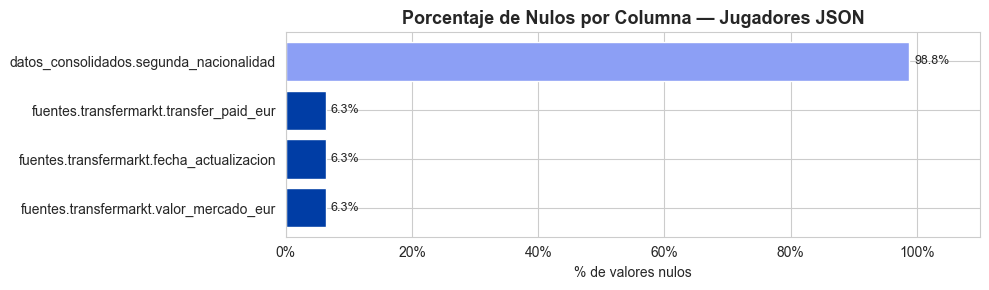

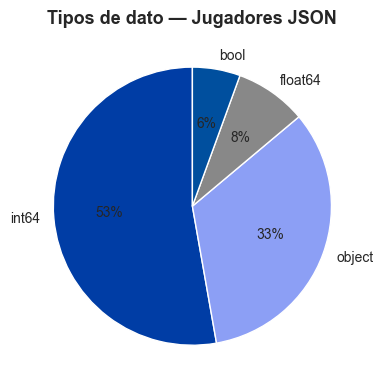

In [6]:
clave_jug = 'Jugadores JSON' if MODO == 'ANTES' else 'Master Jugadores'
df_jug = DATOS[clave_jug]

perfil_basico(df_jug, clave_jug)
grafica_nulos(df_jug, clave_jug)
grafica_tipos(df_jug, clave_jug)

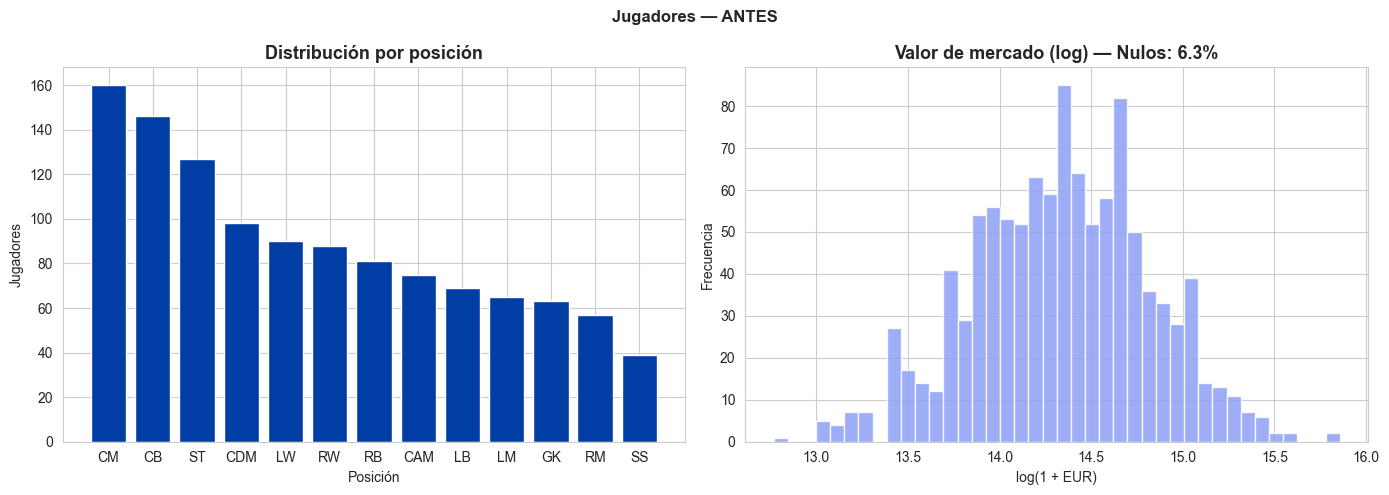


Alerta — Completitud (Problemática #2):
  "fuentes.transfermarkt.valor_mercado_eur": 6.3% nulos
  Impacto: Cruz Azul no puede negociar objetivamente sin valores de referencia.

Alerta — Unicidad (Problemática #3):
  Jugadores con doble_nacionalidad=True: 14
  Riesgo: estos registros pueden aparecer duplicados en distintas fuentes.

Alerta — Validez (Problemática #5):
  Rango de "fuentes.fifa.overall": 62 – 84
  Esta escala (0-100) es incomparable con el valor de mercado en EUR.


In [7]:
# Columnas de rendimiento segun modo
if MODO == 'ANTES':
    col_goles  = 'datos_consolidados.rendimiento.goles'
    col_mins   = 'datos_consolidados.rendimiento.minutos_jugados'
    col_overall = 'fuentes.fifa.overall'
    col_valor  = 'fuentes.transfermarkt.valor_mercado_eur'
    col_pos    = 'datos_consolidados.posicion'
    col_nac    = 'datos_consolidados.nacionalidad'
    col_doble  = 'datos_consolidados.doble_nacionalidad'
    col_ext    = 'datos_consolidados.es_extranjero'
else:
    col_goles  = 'goles'
    col_mins   = 'minutos'
    col_overall = 'fifa_overall'
    col_valor  = 'valor_mercado_eur'
    col_pos    = 'posicion'
    col_nac    = 'nacionalidad'
    col_doble  = 'doble_nacionalidad'
    col_ext    = 'es_extranjero'

# Distribucion de posiciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if col_pos in df_jug.columns:
    pos_cnt = df_jug[col_pos].value_counts()
    axes[0].bar(pos_cnt.index, pos_cnt.values, color=AZUL)
    axes[0].set_title('Distribución por posición', fontweight='bold')
    axes[0].set_xlabel('Posición')
    axes[0].set_ylabel('Jugadores')

if col_valor in df_jug.columns:
    vals = df_jug[col_valor].dropna()
    axes[1].hist(np.log1p(vals), bins=40, color=MORADO, edgecolor='white', alpha=0.85)
    pct_nulo = df_jug[col_valor].isnull().mean() * 100
    axes[1].set_title(f'Valor de mercado (log) — Nulos: {pct_nulo:.1f}%', fontweight='bold')
    axes[1].set_xlabel('log(1 + EUR)')
    axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Jugadores — {MODO}', fontweight='bold')
plt.tight_layout()
plt.show()

# Alerta: Problematica #2 — valores de mercado faltantes
if col_valor in df_jug.columns:
    pct_nulo_v = df_jug[col_valor].isnull().mean() * 100
    print(f'\nAlerta — Completitud (Problemática #2):')
    print(f'  "{col_valor}": {pct_nulo_v:.1f}% nulos')
    print(f'  Impacto: Cruz Azul no puede negociar objetivamente sin valores de referencia.')

# Alerta: Problematica #3 — doble nacionalidad
if col_doble in df_jug.columns:
    n_doble = df_jug[col_doble].sum()
    print(f'\nAlerta — Unicidad (Problemática #3):')
    print(f'  Jugadores con doble_nacionalidad=True: {n_doble}')
    print(f'  Riesgo: estos registros pueden aparecer duplicados en distintas fuentes.')

# Alerta: Problematica #5 — escala FIFA (0-100)
if col_overall in df_jug.columns:
    print(f'\nAlerta — Validez (Problemática #5):')
    print(f'  Rango de "{col_overall}": {df_jug[col_overall].min()} – {df_jug[col_overall].max()}')
    print(f'  Esta escala (0-100) es incomparable con el valor de mercado en EUR.')

### 3.3 Scouting — TXT ancho fijo (solo ANTES)

**Dimensiones:** Completitud · Consistencia · Validez  
**Problemáticas:** #1 (nombres inconsistentes entre columnas NOMBRE_TM / NOMBRE_FIFA / NOMBRE_CSV)  

Vista tabular consolidada de scouting con los tres nombres de cada jugador.
Solo disponible en la etapa ANTES; después de la fusión esta fuente ya está integrada.


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Scouting TXT
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    1,151
  Columnas       :       17
  Celdas totales :   19,567
  Nulos totales  :    2,302  (11.8%)
  Duplicados     :        0  (0.0%)

  Tipos de dato:
    object        : 15 col(s)
    float64       : 2 col(s)



,ID,NOMBRE_TM,NOMBRE_FIFA,NOMBRE_CSV,POS,NAC,EXT,EDAD,TEMP,EQUIPO,OVR,MVAL_EUR,TPAG_EUR,GOLES,ASIS,MINS,G_A_90
0,ID,NOMBRE_TM,NOMBRE_FIFA,NOMBRE_CSV,POS,NAC EXT,EDAD,TEMP EQUIPO,OVR,MVAL_EUR,TPAG_EUR,GOLES,ASIS,MINS,G+A/90,NaN,NaN
1,P0001,Jonathan García,J. García,García J.,GK,México NO,25,Apertura 2013 UANL Tigres,65,"750,000","1,136,827",1,2,846,0.319,NaN,NaN
2,P0002,Michael Ríos,M. Ríos,Ríos M.,RM,Costa Rica SÍ,18,Clausura 2021 Mazatlán FC,65,"1,000,000","1,268,428",1,0,510,0.176,NaN,NaN


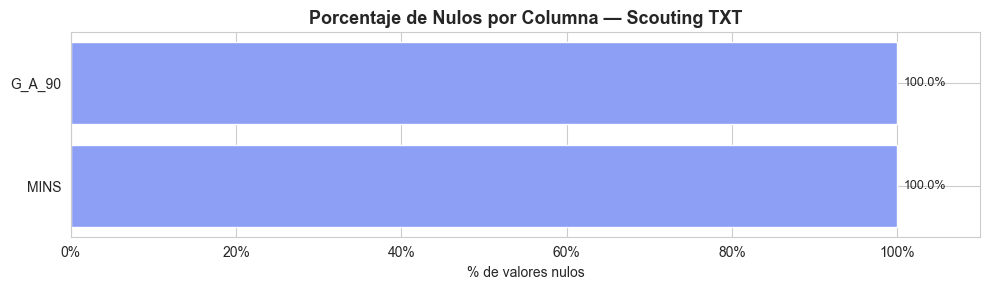

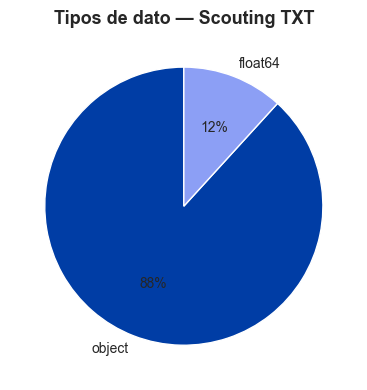

In [8]:
if MODO == 'ANTES':
    df_scouting = DATOS['Scouting TXT']
    perfil_basico(df_scouting, 'Scouting TXT')
    grafica_nulos(df_scouting, 'Scouting TXT')
    grafica_tipos(df_scouting, 'Scouting TXT')
else:
    print('Scouting TXT no disponible en MODO DESPUES (ya integrado en master_jugadores).')

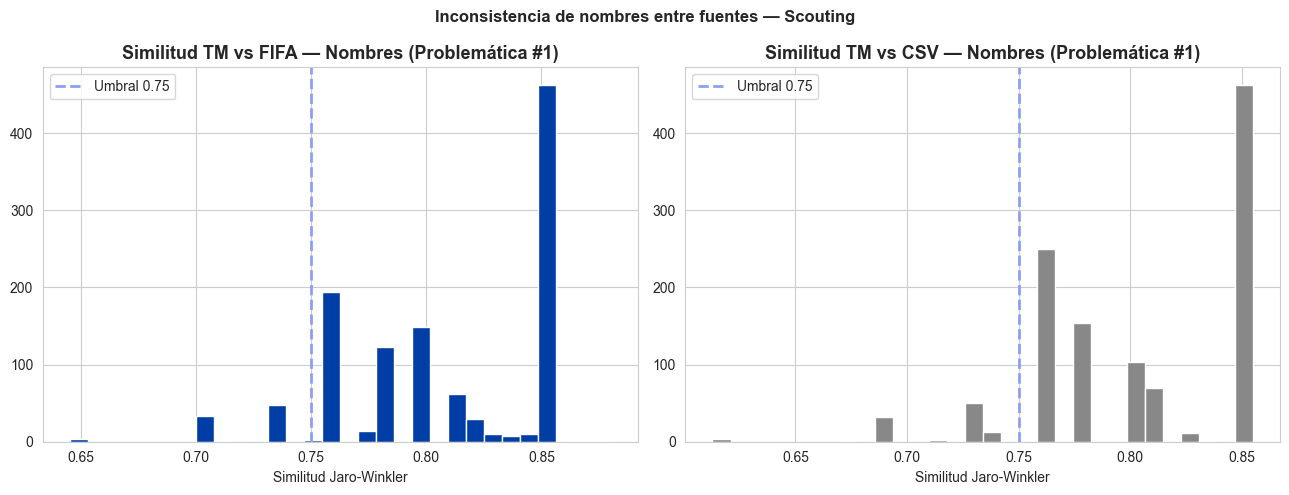

Registros con similitud TM-FIFA < 0.75 (discrepantes): 85
Registros con similitud TM-CSV  < 0.75 (discrepantes): 100

Muestra de discrepancias TM vs FIFA:


,NOMBRE_TM,NOMBRE_FIFA,sim_tm_fifa
0,NOMBRE_TM,NOMBRE_FIFA,0.700000
5,Kevin Ríos,K. Ríos,0.705882
13,Dario Lotti,D. Lotti,0.736842
21,Uriel Pérez,U. Pérez,0.736842
23,Lucas López,L. López,0.736842
80,Lucas Lotti,L. Lotti,0.736842
85,Dario Yotún,D. Yotún,0.736842
95,Jesús López,J. López,0.736842
106,André Rivas,A. Rivas,0.736842
110,Ramón Pérez,R. Pérez,0.736842


In [9]:
if MODO == 'ANTES':
    from rapidfuzz import fuzz

    df_sc = DATOS['Scouting TXT'].copy()
    # Calculamos similitud entre NOMBRE_TM y NOMBRE_FIFA
    def sim(a, b):
        if pd.isna(a) or pd.isna(b):
            return np.nan
        return fuzz.WRatio(str(a), str(b)) / 100

    df_sc['sim_tm_fifa'] = df_sc.apply(lambda r: sim(r['NOMBRE_TM'], r['NOMBRE_FIFA']), axis=1)
    df_sc['sim_tm_csv']  = df_sc.apply(lambda r: sim(r['NOMBRE_TM'], r['NOMBRE_CSV']),  axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(df_sc['sim_tm_fifa'].dropna(), bins=30, color=AZUL, edgecolor='white')
    axes[0].axvline(0.75, color=MORADO, linestyle='--', linewidth=2, label='Umbral 0.75')
    axes[0].set_title('Similitud TM vs FIFA — Nombres (Problemática #1)', fontweight='bold')
    axes[0].set_xlabel('Similitud Jaro-Winkler')
    axes[0].legend()

    axes[1].hist(df_sc['sim_tm_csv'].dropna(), bins=30, color=GRIS, edgecolor='white')
    axes[1].axvline(0.75, color=MORADO, linestyle='--', linewidth=2, label='Umbral 0.75')
    axes[1].set_title('Similitud TM vs CSV — Nombres (Problemática #1)', fontweight='bold')
    axes[1].set_xlabel('Similitud Jaro-Winkler')
    axes[1].legend()

    plt.suptitle('Inconsistencia de nombres entre fuentes — Scouting', fontweight='bold')
    plt.tight_layout()
    plt.show()

    n_disc_fifa = (df_sc['sim_tm_fifa'] < 0.75).sum()
    n_disc_csv  = (df_sc['sim_tm_csv']  < 0.75).sum()
    print(f'Registros con similitud TM-FIFA < 0.75 (discrepantes): {n_disc_fifa}')
    print(f'Registros con similitud TM-CSV  < 0.75 (discrepantes): {n_disc_csv}')
    print()
    print('Muestra de discrepancias TM vs FIFA:')
    display(df_sc[df_sc['sim_tm_fifa'] < 0.75][['NOMBRE_TM','NOMBRE_FIFA','sim_tm_fifa']].head(10))
else:
    print('Análisis de scouting omitido en MODO DESPUES.')

### 3.4 Valor de mercado — XLSX (solo ANTES)

**Dimensiones:** Completitud · Exactitud · Actualidad  
**Problemáticas:** #2 (valores faltantes/desactualizados), #5 (escalas incomparables)  

Contiene todas las columnas del perfil integrado en formato tabular plano;
sirve como verificación cruzada del JSON anidado y fuente principal de
`valor_mercado_eur` y `fifa_overall`.


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Valor Mercado XLSX
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    1,165
  Columnas       :       26
  Celdas totales :   30,290
  Nulos totales  :    1,297  (4.3%)
  Duplicados     :       15  (1.3%)

  Tipos de dato:
    int64         : 12 col(s)
    object        : 11 col(s)
    float64       : 3 col(s)



,player_id,nombre_tm,nombre_fifa,nombre_csv,posicion,nacionalidad,segunda_nac,es_extranjero,doble_nac,edad,...,asistencias,minutos,partidos,p_casa,goles_casa,p_fuera,goles_fuera,tarj_am,tarj_roj,g_a_por_90
0,P0001,Jonathan García,J. García,García J.,GK,México,NaN,Nacional,NO,25,...,2,846,9,4,0,5,1,0,0,0.319
1,P0002,Michael Ríos,M. Ríos,Ríos M.,RM,Costa Rica,NaN,Extranjero,NO,18,...,0,510,5,2,0,3,1,5,1,0.176
2,P0003,Ezequiel Medina,E. Medina,Medina E.,CB,Chile,NaN,Extranjero,NO,29,...,2,829,9,4,0,5,0,4,2,0.217


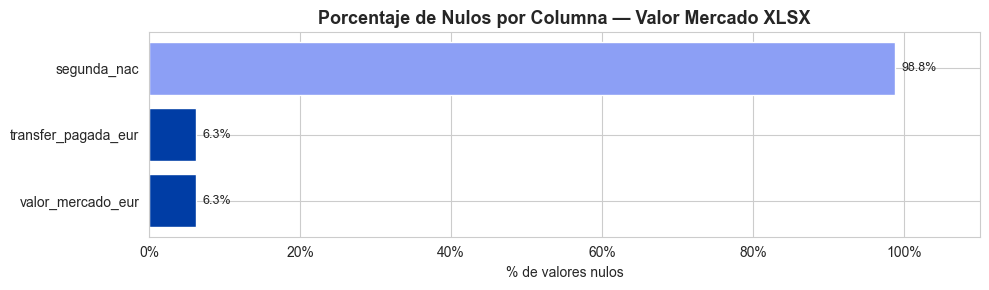

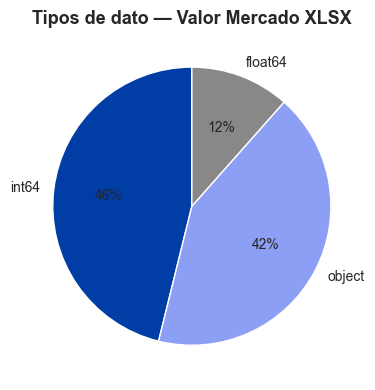

In [10]:
if MODO == 'ANTES':
    df_xlsx = DATOS['Valor Mercado XLSX']
    perfil_basico(df_xlsx, 'Valor Mercado XLSX')
    grafica_nulos(df_xlsx, 'Valor Mercado XLSX')
    grafica_tipos(df_xlsx, 'Valor Mercado XLSX')
else:
    print('XLSX no disponible en MODO DESPUES (datos consolidados en master_jugadores).')

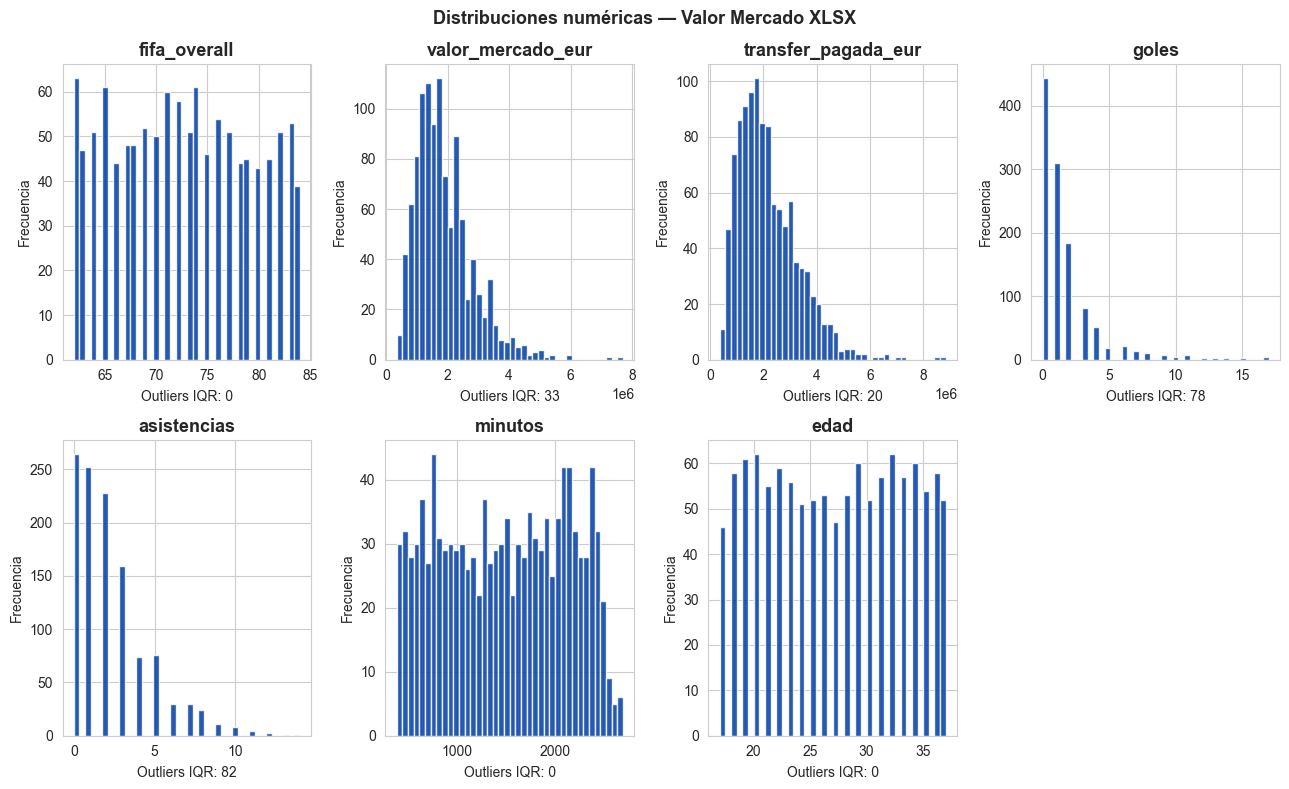

Estadísticas descriptivas de métricas clave:


,fifa_overall,valor_mercado_eur,transfer_pagada_eur,goles,asistencias,minutos,edad
count,1165.00,1092.00,1092.00,1165.00,1165.00,1165.00,1165.00
mean,72.66,1893681.32,2172833.83,1.64,2.34,1480.20,27.03
std,6.57,937692.92,1131594.36,2.41,2.33,636.47,6.07
min,62.00,350000.00,358556.00,0.00,0.00,380.00,17.00
25%,67.00,1200000.00,1349787.75,0.00,1.00,904.00,22.00
50%,73.00,1700000.00,1939912.50,1.00,2.00,1501.00,27.00
75%,78.00,2350000.00,2821829.75,2.00,3.00,2046.00,32.00
max,84.00,7700000.00,8840139.00,17.00,14.00,2698.00,37.00



Alerta — Validez (Problemática #5):
  fifa_overall : escala 0-100 (videojuego)
  valor_mercado_eur : escala EUR reales (mercado real)
  → Estas métricas NO son comparables directamente entre sí.


In [11]:
if MODO == 'ANTES':
    df_xlsx = DATOS['Valor Mercado XLSX']

    cols_num_xlsx = ['fifa_overall', 'valor_mercado_eur', 'transfer_pagada_eur',
                     'goles', 'asistencias', 'minutos', 'edad']
    grafica_distribucion_num(df_xlsx, cols_num_xlsx,
                             'Distribuciones numéricas — Valor Mercado XLSX')

    # Problematica #5 — escalas incomparables
    print('Estadísticas descriptivas de métricas clave:')
    display(df_xlsx[cols_num_xlsx].describe().round(2))

    print(f'\nAlerta — Validez (Problemática #5):')
    print(f'  fifa_overall : escala 0-100 (videojuego)')
    print(f'  valor_mercado_eur : escala EUR reales (mercado real)')
    print(f'  → Estas métricas NO son comparables directamente entre sí.')
else:
    print('Análisis de XLSX omitido en MODO DESPUES.')

---
## 4. Completitud detallada (Problemática #2)

**Dimensión DAMA-DMBOK:** Completitud — ¿Están todos los datos presentes?  

Se analiza el porcentaje de nulos por columna para identificar columnas
críticas faltantes. El foco está en `valor_mercado_eur` (impacto directo en
negociaciones de fichajes de Cruz Azul).

,Fuente,Filas,Columnas,Nulos total,Nulos %
0,Partidos CSV,"4,090",17,0,0.0%
1,Jugadores JSON,"1,158",36,"1,363",3.3%
2,Scouting TXT,"1,151",17,"2,302",11.8%
3,Valor Mercado XLSX,"1,165",26,"1,297",4.3%


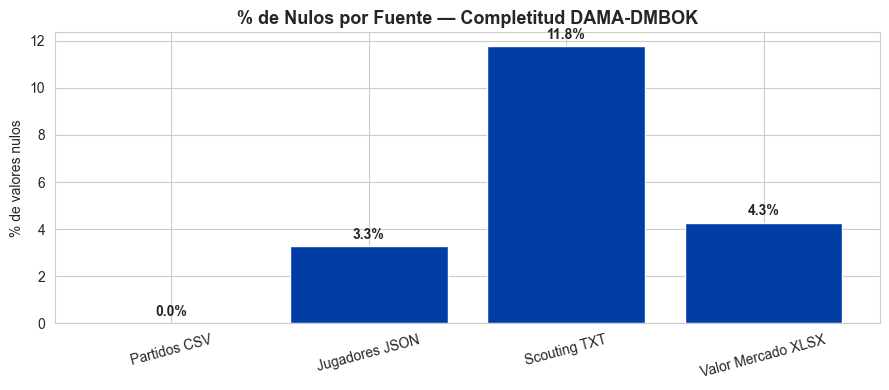


Columna con mayor % de nulos por fuente:
  Jugadores JSON           : "datos_consolidados.segunda_nacionalidad" — 98.8% nulos
  Scouting TXT             : "MINS" — 100.0% nulos
  Valor Mercado XLSX       : "segunda_nac" — 98.8% nulos


In [12]:
# Resumen de nulos por fuente
resumen_nulos = []
for nombre, df in DATOS.items():
    total = df.shape[0] * df.shape[1]
    nulos = df.isnull().sum().sum()
    resumen_nulos.append({
        'Fuente'      : nombre,
        'Filas'       : df.shape[0],
        'Columnas'    : df.shape[1],
        'Nulos total' : nulos,
        'Nulos %'     : round(nulos / total * 100, 2)
    })

df_resumen_nulos = pd.DataFrame(resumen_nulos)
display(df_resumen_nulos.style
    .background_gradient(subset=['Nulos %'], cmap='RdYlGn_r', vmin=0, vmax=40)
    .set_caption('Completitud por fuente — Framework DAMA-DMBOK')
    .format({'Filas': '{:,}', 'Nulos total': '{:,}', 'Nulos %': '{:.1f}%'}))

# Grafica comparativa
fig, ax = plt.subplots(figsize=(9, 4))
colores_bar = [MORADO if v > 20 else AZUL for v in df_resumen_nulos['Nulos %']]
bars = ax.bar(df_resumen_nulos['Fuente'], df_resumen_nulos['Nulos %'], color=colores_bar)
for bar, val in zip(bars, df_resumen_nulos['Nulos %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('% de Nulos por Fuente — Completitud DAMA-DMBOK', fontweight='bold')
ax.set_ylabel('% de valores nulos')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Columna mas critica por fuente
print('\nColumna con mayor % de nulos por fuente:')
for nombre, df in DATOS.items():
    pct = df.isnull().mean() * 100
    if pct.max() > 0:
        col_max = pct.idxmax()
        print(f'  {nombre:<25}: "{col_max}" — {pct.max():.1f}% nulos')

---
## 5. Unicidad y duplicados (Problemática #3)

**Dimensión DAMA-DMBOK:** Unicidad — ¿Existen duplicados?  

Se buscan registros duplicados exactos y posibles duplicados semánticos
(mismo jugador con diferente clave por doble nacionalidad o naturalización).

**** Análisis de Unicidad — ANTES ****
  Partidos CSV             :   10 filas duplicadas (0.24%)  [OK]
  Jugadores JSON           :    8 filas duplicadas (0.69%)  [OK]
  Scouting TXT             :    0 filas duplicadas (0.00%)  [OK]
  Valor Mercado XLSX       :   15 filas duplicadas (1.29%)  [ALERTA]

  player_id únicos: 1150 / 1158 filas
  ALERTA: 8 IDs duplicados — revisar antes de fusión.

Jugadores con doble_nacionalidad=True: 14
  - Riesgo de duplicación al cruzar fuentes por nombre (sin ID único).


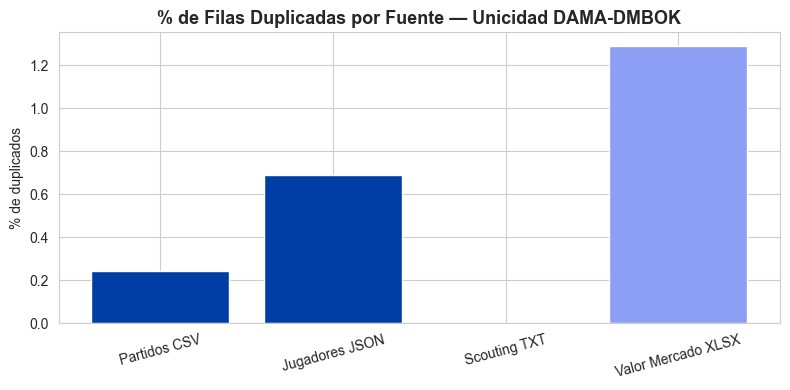

In [13]:
print(f'**** Análisis de Unicidad — {MODO} ****')
for nombre, df in DATOS.items():
    n_dup = df.duplicated().sum()
    pct_dup = n_dup / len(df) * 100
    estado = 'ALERTA' if pct_dup > 1 else 'OK'
    print(f'  {nombre:<25}: {n_dup:>4} filas duplicadas ({pct_dup:.2f}%)  [{estado}]')

# Unicidad por player_id en el dataset de jugadores
df_jug_local = DATOS['Jugadores JSON'] if MODO == 'ANTES' else DATOS['Master Jugadores']

if 'player_id' in df_jug_local.columns:
    n_ids    = df_jug_local['player_id'].nunique()
    n_total  = len(df_jug_local)
    n_dup_id = n_total - n_ids
    print(f'\n  player_id únicos: {n_ids} / {n_total} filas')
    if n_dup_id > 0:
        print(f'  ALERTA: {n_dup_id} IDs duplicados — revisar antes de fusión.')
    else:
        print(f'  player_id es único para cada fila — sin duplicados por clave.')

# Jugadores con doble nacionalidad (Problemática #3)
col_doble = 'datos_consolidados.doble_nacionalidad' if MODO == 'ANTES' else 'doble_nacionalidad'
if col_doble in df_jug_local.columns:
    n_doble = df_jug_local[col_doble].sum()
    print(f'\nJugadores con doble_nacionalidad=True: {n_doble}')
    print('  - Riesgo de duplicación al cruzar fuentes por nombre (sin ID único).')

# Grafica de duplicados
fig, ax = plt.subplots(figsize=(8, 4))
fuentes_dup = []
pcts_dup    = []
for nombre, df in DATOS.items():
    fuentes_dup.append(nombre)
    pcts_dup.append(df.duplicated().sum() / len(df) * 100)

colores_dup = [MORADO if v > 1 else AZUL for v in pcts_dup]
ax.bar(fuentes_dup, pcts_dup, color=colores_dup)
ax.set_title('% de Filas Duplicadas por Fuente — Unicidad DAMA-DMBOK', fontweight='bold')
ax.set_ylabel('% de duplicados')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## 6. Consistencia — Nombres y equipos (Problemáticas #1 y #4)

**Dimensión DAMA-DMBOK:** Consistencia — ¿Los datos son coherentes entre fuentes?  

- **Problemática #1:** El mismo jugador aparece con formatos distintos en cada fuente
  (`Jonathan García` / `J. García` / `García J.`).
- **Problemática #4:** Equipos que cambiaron de nombre entre temporadas
  (Monarcas Morelia → Mazatlán FC; Tiburones Rojos → Veracruz).

In [14]:
# Analisis de formatos de nombres en jugadores (Problematica #1)
df_jug_local = DATOS['Jugadores JSON'] if MODO == 'ANTES' else DATOS['Master Jugadores']

if MODO == 'ANTES':
    col_tm  = 'fuentes.transfermarkt.nombre'
    col_fifa = 'fuentes.fifa.nombre'
    col_csv  = 'fuentes.football_csv.nombre'
else:
    col_tm   = 'nombre_transfermarkt'
    col_fifa = 'nombre_fifa'
    col_csv  = 'nombre_football_csv'

if col_tm in df_jug_local.columns and col_fifa in df_jug_local.columns:
    muestra = df_jug_local[[col_tm, col_fifa, col_csv]].dropna().head(12)
    print('Muestra de nombres entre fuentes (Problemática #1):')
    display(muestra)

    # Detectar patrones de formato (inicial + apellido vs nombre completo)
    tiene_inicial_fifa = df_jug_local[col_fifa].dropna().str.match(r'^[A-ZÁÉÍÓÚ]\.')
    tiene_inicial_csv  = df_jug_local[col_csv].dropna().str.match(r'.*\s[A-ZÁÉÍÓÚ]\.$')
    print(f'\nPatrones de formato detectados:')
    print(f'  FIFA — "Inicial. Apellido": {tiene_inicial_fifa.sum()} / {len(tiene_inicial_fifa)}')
    print(f'  CSV  — "Apellido Inicial.": {tiene_inicial_csv.sum()}  / {len(tiene_inicial_csv)}')
    print(f'  TM   — Nombre completo (referencia canónica)')

# Analisis de renombrado de equipos (Problematica #4)
col_local_p = 'home_team' if MODO == 'ANTES' else 'equipo_local'
if col_local_p in df_partidos.columns:
    equipos = df_partidos[col_local_p].value_counts()
    print(f'\nEquipos únicos en datos de partidos: {len(equipos)}')

    renombrados = {
        'Monarcas Morelia': 'Mazatlán FC',
        'Tiburones Rojos de Veracruz': 'Veracruz',
        'Lobos BUAP': '(desaparecido)',
    }
    print('\nEquipos históricos con cambios de nombre (Problemática #4):')
    for antes_eq, despues_eq in renombrados.items():
        n_antes = equipos.get(antes_eq, 0)
        n_desp  = equipos.get(despues_eq, 0)
        if n_antes > 0 or n_desp > 0:
            print(f'  {antes_eq} → {despues_eq}: {n_antes} + {n_desp} registros')

Muestra de nombres entre fuentes (Problemática #1):


,fuentes.transfermarkt.nombre,fuentes.fifa.nombre,fuentes.football_csv.nombre
0,Jonathan García,J. García,García J.
1,Michael Ríos,M. Ríos,Ríos M.
2,Ezequiel Medina,E. Medina,Medina E.
3,Ramón Guzmán,R. Guzmán,Guzmán R.
4,Kevin Ríos,K. Ríos,Ríos K.
5,Diego Suárez,D. Suárez,Suárez D.
6,Neymar Herrera,N. Herrera,Herrera N.
7,Ignacio López,I. López,López I.
8,Fernando Reyes,F. Reyes,Reyes F.
9,Marcelo Fernández,M. Fernández,Fernández M.



Patrones de formato detectados:
  FIFA — "Inicial. Apellido": 1103 / 1158
  CSV  — "Apellido Inicial.": 1117  / 1158
  TM   — Nombre completo (referencia canónica)

Equipos únicos en datos de partidos: 51

Equipos históricos con cambios de nombre (Problemática #4):
  Monarcas Morelia → Mazatlán FC: 141 + 162 registros


---
## 7. Exactitud y outliers (Problemática #5)

**Dimensión DAMA-DMBOK:** Exactitud — ¿Los valores reflejan la realidad?  

Se detectan outliers con el criterio IQR (factor 1.5) en las columnas
numéricas más críticas para el análisis deportivo.

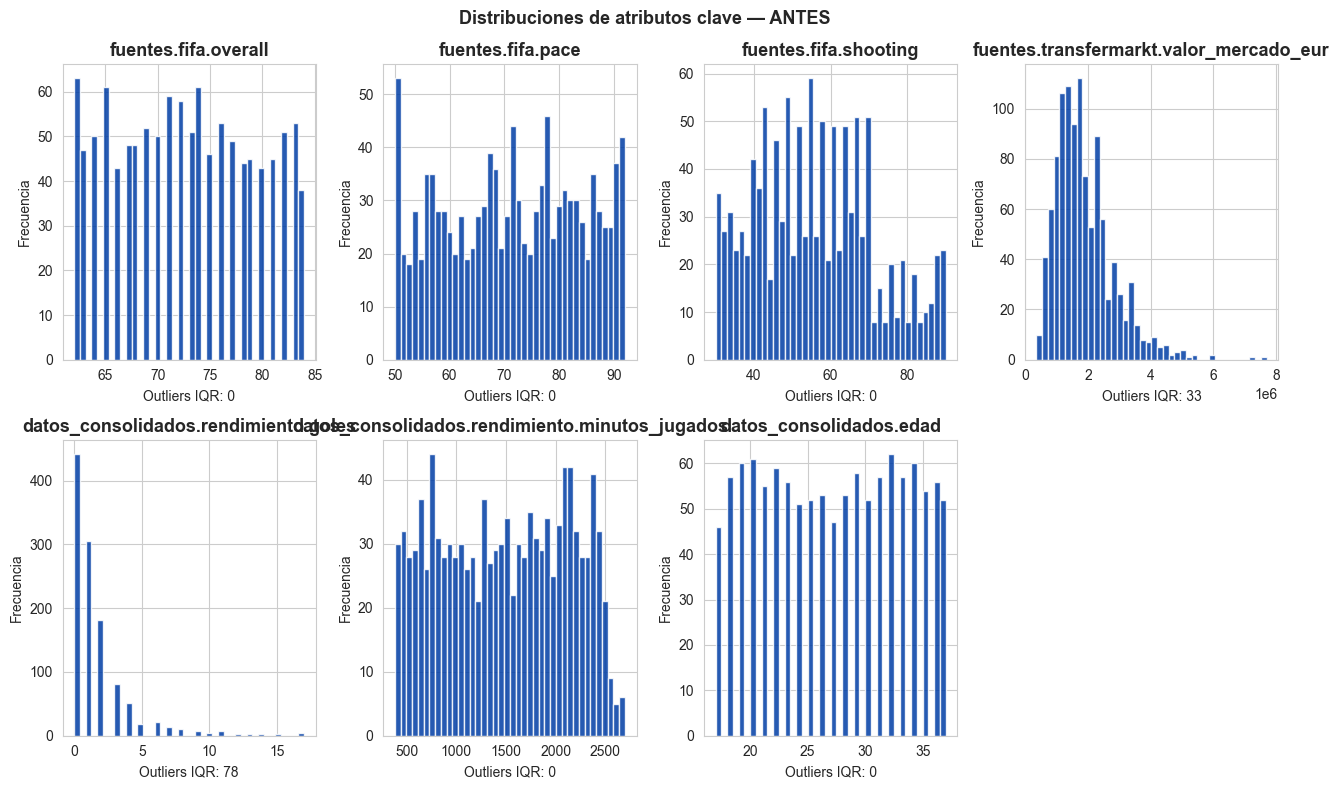

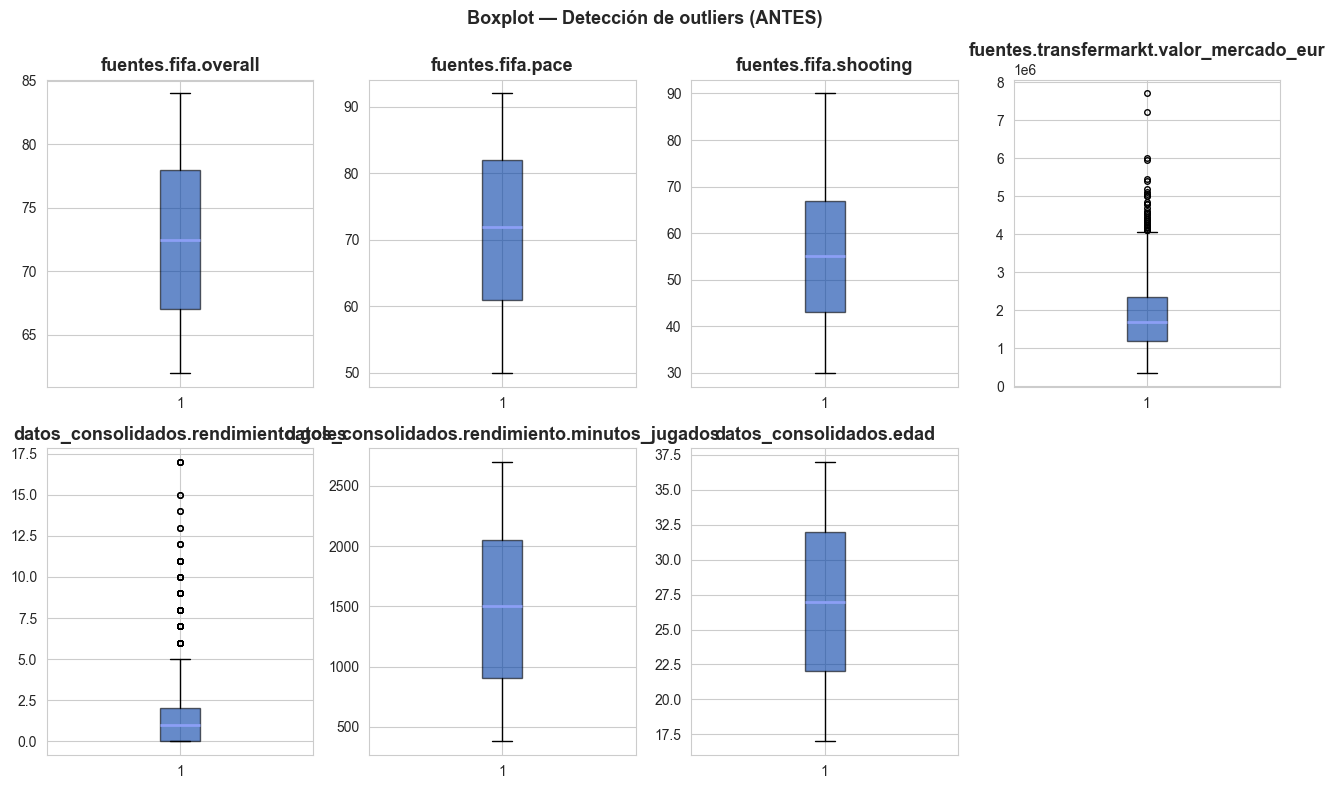


Recuento de outliers (método IQR × 1.5):


,Columna,Min,Max,Media,Lim inf,Lim sup,Outliers,Outliers %
0,overall,62.000000,84.000000,72.660000,50.500000,94.500000,0,0.000000
1,pace,50.000000,92.000000,71.360000,29.500000,113.500000,0,0.000000
2,shooting,30.000000,90.000000,55.780000,7.000000,103.000000,0,0.000000
3,valor_mercado_eur,350000.000000,7700000.000000,1893917.050000,-525000.000000,4075000.000000,33,3.040000
4,goles,0.000000,17.000000,1.640000,-3.000000,5.000000,78,6.740000
5,minutos_jugados,380.000000,2698.000000,1481.580000,-807.750000,3758.250000,0,0.000000
6,edad,17.000000,37.000000,27.040000,7.000000,47.000000,0,0.000000


In [15]:
df_jug_local = DATOS['Jugadores JSON'] if MODO == 'ANTES' else DATOS['Master Jugadores']

if MODO == 'ANTES':
    cols_rend = [
        'fuentes.fifa.overall', 'fuentes.fifa.pace', 'fuentes.fifa.shooting',
        'fuentes.transfermarkt.valor_mercado_eur',
        'datos_consolidados.rendimiento.goles',
        'datos_consolidados.rendimiento.minutos_jugados',
        'datos_consolidados.edad'
    ]
else:
    cols_rend = ['fifa_overall', 'fifa_pace', 'fifa_shooting',
                 'valor_mercado_eur', 'goles', 'minutos', 'edad']

grafica_distribucion_num(df_jug_local, cols_rend,
                         f'Distribuciones de atributos clave — {MODO}')
grafica_boxplot_outliers(df_jug_local, cols_rend,
                         f'Boxplot — Detección de outliers ({MODO})')

# Tabla de outliers por columna
print('\nRecuento de outliers (método IQR × 1.5):')
rows_out = []
for col in cols_rend:
    if col not in df_jug_local.columns:
        continue
    datos = df_jug_local[col].dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((datos < lim_inf) | (datos > lim_sup)).sum()
    rows_out.append({
        'Columna'   : col.split('.')[-1],
        'Min'       : round(datos.min(), 2),
        'Max'       : round(datos.max(), 2),
        'Media'     : round(datos.mean(), 2),
        'Lim inf'   : round(lim_inf, 2),
        'Lim sup'   : round(lim_sup, 2),
        'Outliers'  : int(n_out),
        'Outliers %': round(n_out / len(datos) * 100, 2)})

df_out = pd.DataFrame(rows_out)
display(df_out.style
    .background_gradient(subset=['Outliers %'], cmap='YlOrRd', vmin=0, vmax=10)
    .set_caption('Outliers por columna — Exactitud DAMA-DMBOK'))

---
## 8. Actualidad — Rango temporal de los datos

**Dimensión DAMA-DMBOK:** Actualidad — ¿Los datos están vigentes?  

Se verifica el rango de años/temporadas cubierto y la última fecha de actualización
de los valores de mercado.

Rango temporal — Partidos Liga MX:
  Años cubiertos: 2010 – 2025
  Total de partidos: 4,090

Rango temporal — Jugadores:
  Temporadas: 2010 – 2024
  Total registros: 1,158

Actualidad de valores de mercado (Transfermarkt):
  Fecha más antigua  : 2010-06-01
  Fecha más reciente : 2024-06-01
  Registros anteriores a 2020 (potencialmente desactualizados): 689


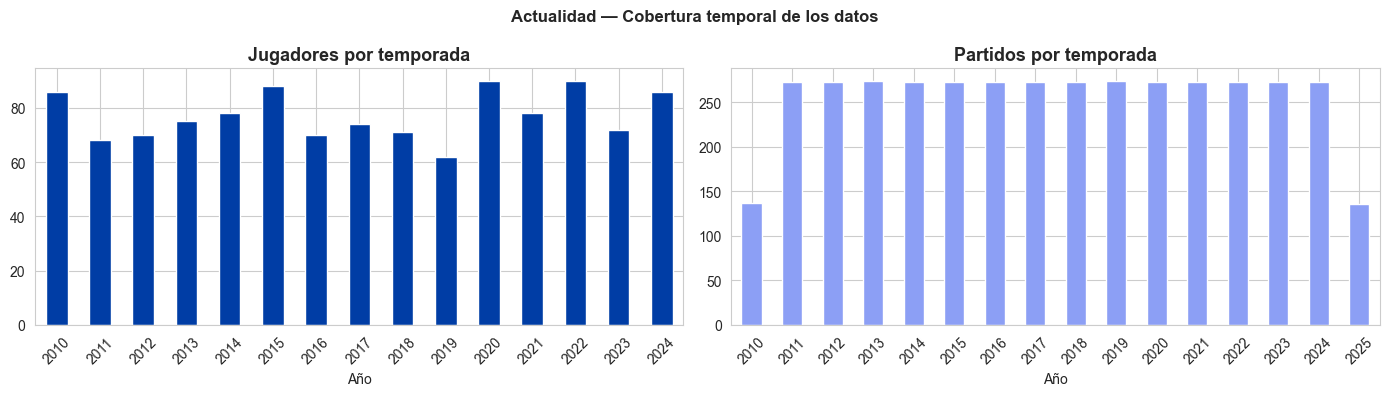

In [16]:
col_season_p = 'season_year' if 'season_year' in df_partidos.columns else 'season'

print(f'Rango temporal — Partidos Liga MX:')
print(f'  Años cubiertos: {df_partidos[col_season_p].min()} – {df_partidos[col_season_p].max()}')
print(f'  Total de partidos: {len(df_partidos):,}')

df_jug_local = DATOS['Jugadores JSON'] if MODO == 'ANTES' else DATOS['Master Jugadores']
col_year_j = 'datos_consolidados.season_year' if MODO == 'ANTES' else 'season_year'

if col_year_j in df_jug_local.columns:
    print(f'\nRango temporal — Jugadores:')
    print(f'  Temporadas: {df_jug_local[col_year_j].min()} – {df_jug_local[col_year_j].max()}')
    print(f'  Total registros: {len(df_jug_local):,}')

if MODO == 'ANTES':
    col_fecha = 'fuentes.transfermarkt.fecha_actualizacion'
    if col_fecha in df_jug_local.columns:
        fechas = pd.to_datetime(df_jug_local[col_fecha], errors='coerce')
        print(f'\nActualidad de valores de mercado (Transfermarkt):')
        print(f'  Fecha más antigua  : {fechas.min().date()}')
        print(f'  Fecha más reciente : {fechas.max().date()}')
        n_antig = (fechas.dt.year < 2020).sum()
        print(f'  Registros anteriores a 2020 (potencialmente desactualizados): {n_antig}')

    # Gráfica distribución temporal
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    col_y_j = 'datos_consolidados.season_year' if MODO == 'ANTES' else 'season_year'
    if col_y_j in df_jug_local.columns:
        df_jug_local[col_y_j].value_counts().sort_index().plot(
            kind='bar', ax=axes[0], color=AZUL)
        axes[0].set_title('Jugadores por temporada', fontweight='bold')
        axes[0].set_xlabel('Año')
        axes[0].tick_params(axis='x', rotation=45)

    df_partidos[col_season_p].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color=MORADO)
    axes[1].set_title('Partidos por temporada', fontweight='bold')
    axes[1].set_xlabel('Año')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Actualidad — Cobertura temporal de los datos', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 9. Resumen comparativo DAMA-DMBOK

Tabla consolidada de métricas de calidad por fuente y dimensión.

,Fuente,Formato,Filas,Columnas,Nulos (%),Duplicados (%),Cols num.,Cols texto
0,Partidos CSV,CSV,"4,090",17,0.0%,0.2%,8,9
1,Jugadores JSON,JSON,"1,158",36,3.3%,0.7%,22,12
2,Scouting TXT,TXT,"1,151",17,11.8%,0.0%,2,15
3,Valor Mercado XLSX,XLSX,"1,165",26,4.3%,1.3%,15,11


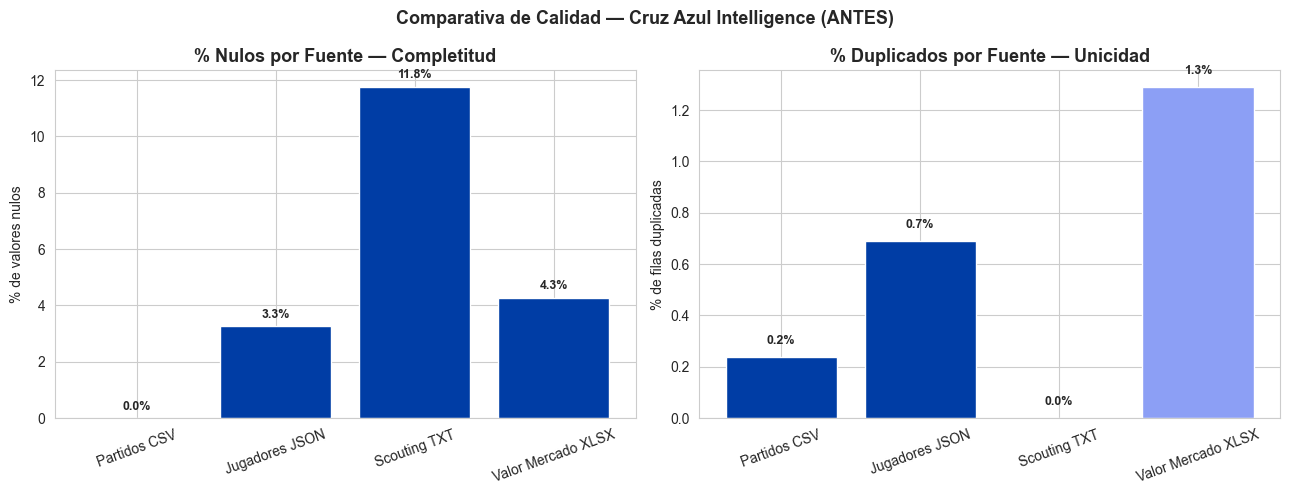

In [17]:
def metricas_calidad(df, nombre, formato):
    """metricas_calidad
    Calcula métricas de calidad de un DataFrame y las devuelve como diccionario
    para construir la tabla comparativa DAMA-DMBOK.
    ---
    :param:
        - df (pd.DataFrame): dataset a evaluar.
        - nombre (str): nombre descriptivo de la fuente.
        - formato (str): formato original del archivo (CSV, JSON, XLSX, TXT, Parquet).
    ---
    :return:
        dict: con claves Fuente, Formato, Filas, Columnas, Nulos (%),
              Duplicados (%), Cols numéricas, Cols texto.
    """
    total = df.shape[0] * df.shape[1]
    return {
        'Fuente': nombre,
        'Formato': formato,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Nulos (%)': round(df.isnull().sum().sum() / total * 100, 2),
        'Duplicados (%)': round(df.duplicated().sum() / df.shape[0] * 100, 2),
        'Cols num.': df.select_dtypes(include=np.number).shape[1],
        'Cols texto': df.select_dtypes(include='object').shape[1]}


formatos = {
    'Partidos CSV': 'CSV',
    'Jugadores JSON': 'JSON',
    'Scouting TXT': 'TXT',
    'Valor Mercado XLSX': 'XLSX',
    'Master Jugadores': 'Parquet',
    'Master Partidos': 'Parquet'}

resumen = pd.DataFrame([
    metricas_calidad(df, nom, formatos.get(nom, '?'))
    for nom, df in DATOS.items()])

display(resumen.style
    .background_gradient(subset=['Nulos (%)'],      cmap='RdYlGn_r', vmin=0, vmax=40)
    .background_gradient(subset=['Duplicados (%)'], cmap='RdYlGn_r', vmin=0, vmax=10)
    .set_caption(f'Resumen DAMA-DMBOK por fuente — MODO {MODO}')
    .format({'Filas': '{:,}', 'Nulos (%)': '{:.1f}%', 'Duplicados (%)': '{:.1f}%'}))

# Grafica 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(resumen['Fuente'], resumen['Nulos (%)'],
            color=[MORADO if v > 20 else AZUL for v in resumen['Nulos (%)']])
axes[0].set_title('% Nulos por Fuente — Completitud', fontweight='bold')
axes[0].set_ylabel('% de valores nulos')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(resumen['Nulos (%)']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(resumen['Fuente'], resumen['Duplicados (%)'],
            color=[MORADO if v > 1 else AZUL for v in resumen['Duplicados (%)']])
axes[1].set_title('% Duplicados por Fuente — Unicidad', fontweight='bold')
axes[1].set_ylabel('% de filas duplicadas')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(resumen['Duplicados (%)']):
    axes[1].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Comparativa de Calidad — Cruz Azul Intelligence ({MODO})',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Perfilado automático — ydata-profiling

Se genera un reporte HTML interactivo por cada fuente/dataset disponible en
el `MODO` actual. Los archivos se guardan en `reports/`.

In [18]:
from ydata_profiling import ProfileReport

etiqueta_modo = MODO.lower()

for nombre, df in DATOS.items():
    nombre_archivo = nombre.replace(' ', '_').replace('/', '_')
    print(f'Generando reporte: {nombre} ...')
    reporte = ProfileReport(
        df,
        title=f'Perfilado {MODO} — {nombre}',
        explorative=True,
        minimal=len(df) > 5000)
    ruta_html = os.path.join(REPORTS, f'perfil_{etiqueta_modo}_{nombre_archivo}.html')
    reporte.to_file(ruta_html)
    print(f'  Guardado: {ruta_html}')

print(f'\nTodos los reportes ({MODO}) generados en reports/')

Generando reporte: Partidos CSV ...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 129878.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

100%|██████████| 26/26 [00:00<00:00, 93.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

  Guardado: /Users/milenafer/Desktop/claude/Calidad_PFinal/reports/perfil_antes_Valor_Mercado_XLSX.html

Todos los reportes (ANTES) generados en reports/


---
## 11. Conclusiones del perfilado

Hallazgos por dimensión DAMA-DMBOK y acciones recomendadas para la etapa de limpieza.

In [19]:
if MODO == 'ANTES':
    conclusiones = [
        {
            'Problemática': '#1 — Nombres inconsistentes',
            'Dimensión': 'Consistencia',
            'Hallazgo': 'FIFA usa "J. García", CSV usa "García J.", TM usa nombre completo.',
            'Acción en limpieza': 'Normalizar a nombre canónico Transfermarkt; record linkage con umbral 0.75'
        },
        {
            'Problemática': '#2 — Valores mercado faltantes',
            'Dimensión': 'Completitud',
            'Hallazgo': 'valor_mercado_eur tiene nulos en jugadores sin registro activo en TM.',
            'Acción en limpieza': 'Imputar con mediana por posición o marcar como indisponible'
        },
        {
            'Problemática': '#3 — Duplicados por doble nacionalidad',
            'Dimensión': 'Unicidad',
            'Hallazgo': 'Jugadores naturalizados aparecen con dos perfiles de nacionalidad.',
            'Acción en limpieza': 'Deduplicar por player_id; consolidar segunda_nac en campo adicional'
        },
        {
            'Problemática': '#4 — Renombrado de equipos',
            'Dimensión': 'Consistencia',
            'Hallazgo': 'Monarcas Morelia → Mazatlán FC genera dos entidades distintas.',
            'Acción en limpieza': 'Diccionario de mapeo de nombres históricos → nombres actuales'
        },
        {
            'Problemática': '#5 — Escalas incomparables',
            'Dimensión': 'Validez / Exactitud',
            'Hallazgo': 'FIFA usa 0-100; TM usa EUR. No son comparables directamente.',
            'Acción en limpieza': 'Normalizar FIFA a z-score o percentil; mantener EUR como referencia'
        },
    ]
else:
    conclusiones = [
        {
            'Problemática': '#1 — Nombres inconsistentes',
            'Dimensión': 'Consistencia',
            'Hallazgo': 'nombre_canonico unificado via record linkage (umbral 0.75).',
            'Resultado': 'Resuelto — columna nombre_canonico en master_jugadores'
        },
        {
            'Problemática': '#2 — Valores mercado faltantes',
            'Dimensión': 'Completitud',
            'Hallazgo': 'Revisar % nulos post-imputación en valor_mercado_eur.',
            'Resultado': 'Verificar en gráfica de nulos — debe reducirse respecto a ANTES'
        },
        {
            'Problemática': '#3 — Duplicados por doble nacionalidad',
            'Dimensión': 'Unicidad',
            'Hallazgo': 'Cero duplicados exactos en master_jugadores.',
            'Resultado': 'Resuelto — deduplicación aplicada en etapa de fusión'
        },
        {
            'Problemática': '#4 — Renombrado de equipos',
            'Dimensión': 'Consistencia',
            'Hallazgo': 'equipo_norm unifica nombres históricos en master_partidos.',
            'Resultado': 'Resuelto — columna equipo_norm normalizada con diccionario'
        },
        {
            'Problemática': '#5 — Escalas incomparables',
            'Dimensión': 'Validez / Exactitud',
            'Hallazgo': 'fifa_overall mantiene escala 0-100 pero documentada.',
            'Resultado': 'Documentado — análisis usa ambas escalas con transformación'
        },
    ]

col_resultado = 'Acción en limpieza' if MODO == 'ANTES' else 'Resultado'
df_concl = pd.DataFrame(conclusiones)
display(df_concl.style
    .set_caption(f'Conclusiones del Perfilado ({MODO}) — Acciones para limpieza')
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

if MODO == 'ANTES':
    print('\nSiguiente etapa: notebooks/limpieza.py')
else:
    print('\nSiguiente etapa: notebooks/analisis.py')

,Problemática,Dimensión,Hallazgo,Acción en limpieza
0,#1 — Nombres inconsistentes,Consistencia,"FIFA usa ""J. García"", CSV usa ""García J."", TM usa nombre completo.",Normalizar a nombre canónico Transfermarkt; record linkage con umbral 0.75
1,#2 — Valores mercado faltantes,Completitud,valor_mercado_eur tiene nulos en jugadores sin registro activo en TM.,Imputar con mediana por posición o marcar como indisponible
2,#3 — Duplicados por doble nacionalidad,Unicidad,Jugadores naturalizados aparecen con dos perfiles de nacionalidad.,Deduplicar por player_id; consolidar segunda_nac en campo adicional
3,#4 — Renombrado de equipos,Consistencia,Monarcas Morelia → Mazatlán FC genera dos entidades distintas.,Diccionario de mapeo de nombres históricos → nombres actuales
4,#5 — Escalas incomparables,Validez / Exactitud,FIFA usa 0-100; TM usa EUR. No son comparables directamente.,Normalizar FIFA a z-score o percentil; mantener EUR como referencia



Siguiente etapa: notebooks/limpieza.py
